# Demo II: hard constraints, routes to a symmetric model

Target: the energy of a 6-atom cluster, Lennard-Jones + Axilrod-Teller three-body term.
The energy is invariant to rotations, translations and permutations of identical atoms.

Four models, same training data and budget:

| model | how the symmetry is handled |
|---|---|
| (a) MLP on raw coordinates | not at all |
| (b) same MLP + random rotations/permutations of the training data | **soft** (augmentation) |
| (c) same MLP after **canonicalisation** (inertia frame + atom sorting) | **hard** |
| (d) atom-centred model on **invariant descriptors**, $E=\sum_i \varepsilon_\theta(G_i)$ | **hard** |

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.set_default_dtype(torch.float64)
torch.set_num_threads(4)
t_start = time.time()

BLUE, RED, GREEN, ORANGE, GREY = "#5073B8", "#B85050", "#50B873", "#EBA05A", "#888888"
COLORS = {"a": RED, "b": ORANGE, "c": GREEN, "d": BLUE}
LABELS = {"a": "(a) raw coordinates", "b": "(b) augmentation (soft)",
          "c": "(c) canonicalisation (hard)", "d": "(d) invariant descriptors (hard)"}
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

N_ATOMS = 6

## The physics: Lennard-Jones + Axilrod-Teller

In [2]:
def energy(X, nu=0.5):
    """X: (B, N, 3) -> (B,) energy, LJ pairs (eps=sigma=1) + Axilrod-Teller triplets."""
    diff = X[:, :, None, :] - X[:, None, :, :]
    r = torch.sqrt((diff**2).sum(-1) + torch.eye(N_ATOMS))       # avoid sqrt(0) on diagonal
    iu = torch.triu_indices(N_ATOMS, N_ATOMS, 1)
    rp = r[:, iu[0], iu[1]]
    e_lj = (4 * (rp**-12 - rp**-6)).sum(-1)
    e_at = 0.0
    for i in range(N_ATOMS):
        for j in range(i + 1, N_ATOMS):
            for k in range(j + 1, N_ATOMS):
                rij, rik, rjk = r[:, i, j], r[:, i, k], r[:, j, k]
                ci = (rij**2 + rik**2 - rjk**2) / (2 * rij * rik)
                cj = (rij**2 + rjk**2 - rik**2) / (2 * rij * rjk)
                ck = (rik**2 + rjk**2 - rij**2) / (2 * rik * rjk)
                e_at = e_at + nu * (1 + 3 * ci * cj * ck) / (rij * rik * rjk) ** 3
    return e_lj + e_at


def random_rotations(B, gen):
    q, r = torch.linalg.qr(torch.randn(B, 3, 3, generator=gen))
    q = q * torch.sign(torch.diagonal(r, dim1=-2, dim2=-1))[:, None, :]
    det = torch.linalg.det(q)
    q[:, :, 0] *= det[:, None]                                    # proper rotations
    return q


def random_permutations(B, gen):
    return torch.argsort(torch.rand(B, N_ATOMS, generator=gen), dim=1)


def rotate_permute(X, gen):
    R = random_rotations(len(X), gen)
    P = random_permutations(len(X), gen)
    Xp = torch.gather(X, 1, P[:, :, None].expand(-1, -1, 3))
    return Xp @ R.transpose(1, 2)

## Canonicalisation: inertia frame, sign convention, atom ordering

In [3]:
U_SORT = torch.tensor([1.0, 0.6, 0.3]) / np.sqrt(1 + 0.36 + 0.09)   # sorting direction (re-chosen below)
_dirs = torch.nn.functional.normalize(torch.randn(500, 3, generator=torch.Generator().manual_seed(3)), dim=1)


def best_direction(Y):
    """Direction (in the canonical frame) along which the atoms are best separated."""
    gaps = torch.diff(torch.sort(Y @ _dirs.T, dim=0).values, dim=0).min(0).values
    return _dirs[torch.argmax(gaps)], gaps.max().item()


def canonicalise(X):
    Xc = X - X.mean(1, keepdim=True)
    cov = Xc.transpose(1, 2) @ Xc
    _, vecs = torch.linalg.eigh(cov)                    # principal axes, ascending
    Y = Xc @ vecs
    sign = torch.sign((Y**3).sum(1, keepdim=True))      # third moment fixes the sign of each axis
    Y = Y * sign
    order = torch.argsort(Y @ U_SORT, dim=1)            # permutation: sort atoms along U_SORT
    return torch.gather(Y, 1, order[:, :, None].expand(-1, -1, 3))

## Reference geometry and datasets
We pick a compact, non-symmetric reference cluster (so that canonicalisation is
well defined), then sample thermal-like perturbations around it.

In [4]:
def make_reference(n_candidates=400):
    """Among partially relaxed random clusters, keep the one whose canonical frame and atom
    ordering are the most robust to thermal noise: well-separated moments of inertia,
    large third moments (sign convention) and well-separated atom projections (ordering)."""
    X = torch.cat([(torch.rand(1, N_ATOMS, 3, generator=torch.Generator().manual_seed(seed)) - 0.5) * 2.2
                   for seed in range(n_candidates)]).requires_grad_(True)
    for _ in range(60):                                  # partial relaxation only, all at once
        (grad,) = torch.autograd.grad(energy(X).sum(), X)
        with torch.no_grad():
            X -= 0.002 * grad.clamp(-50, 50)
    X = X.detach()
    best, best_score = None, 0.0
    for x in X:
        xc = x - x.mean(0)
        moments, vecs = torch.linalg.eigh(xc.T @ xc)
        gaps_m = (moments[1:] - moments[:-1]) / moments.mean()
        third = ((xc @ vecs) ** 3).sum(0).abs()
        u, gap = best_direction(canonicalise(x[None])[0])
        score = min(gap / 0.3, third.min().item() / 0.5, gaps_m.min().item() / 0.3)
        if torch.cdist(x, x).max() < 2.8 and score > best_score:
            best, best_score, best_u = xc, score, u
            info = (gap, third.min().item(), gaps_m.min().item())
    print(f"reference: E = {energy(best[None]).item():.2f}, projection gap = {info[0]:.2f}, "
          f"min |third moment| = {info[1]:.2f}, min relative moment gap = {info[2]:.2f}")
    return best, best_u


X_ref, U_SORT = make_reference()


def sample(n, gen, sigma=0.03):
    X = X_ref + sigma * torch.randn(n, N_ATOMS, 3, generator=gen)
    return X, energy(X)


gen = torch.Generator().manual_seed(42)
X_pool, E_pool = sample(4000, gen)           # training pool, ONE orientation and atom order
X_test0, E_test = sample(1000, gen)          # test configurations ...
X_test = rotate_permute(X_test0, gen)        # ... randomly rotated and permuted
print(f"energy range: {E_pool.min():.2f} to {E_pool.max():.2f}")

reference: E = -5.80, projection gap = 0.33, min |third moment| = 0.37, min relative moment gap = 0.46
energy range: -6.12 to -0.61


## Invariant descriptors (Behler-Parrinello style symmetry functions)

In [5]:
SHIFTS = torch.linspace(0.9, 2.8, 12)
N_DESC = 12 + 16


def descriptors(X):
    """(B, N, 3) -> (B, N, 28): radial + angular symmetry functions per atom."""
    diff = X[:, :, None, :] - X[:, None, :, :]
    r = torch.sqrt((diff**2).sum(-1) + 1e-12)
    mask = 1 - torch.eye(N_ATOMS)
    g_rad = (torch.exp(-6.0 * (r[..., None] - SHIFTS) ** 2) * mask[..., None]).sum(2)
    unit = diff / r[..., None]
    cos = torch.einsum("bijx,bikx->bijk", unit, unit)                 # angle j-i-k
    m3 = mask[:, :, None] * mask[:, None, :] * (1 - torch.eye(N_ATOMS))[None]
    r2 = r[:, :, :, None] ** 2 + r[:, :, None, :] ** 2
    g_ang = [((1 + lam * cos) ** zeta * torch.exp(-eta * r2) * m3).sum((2, 3)) * 2 ** (1 - zeta)
             for lam in (1, -1) for zeta in (1, 2, 4, 8) for eta in (0.3, 1.0)]
    return torch.cat([g_rad, torch.stack(g_ang, -1)], -1)

## The four models

In [6]:
def mlp(n_in, width=64):
    return torch.nn.Sequential(torch.nn.Linear(n_in, width), torch.nn.SiLU(),
                               torch.nn.Linear(width, width), torch.nn.SiLU(),
                               torch.nn.Linear(width, 1))


class Model(torch.nn.Module):
    def __init__(self, kind):
        super().__init__()
        self.kind = kind
        self.net = mlp(N_DESC) if kind == "d" else mlp(3 * N_ATOMS)

    def features(self, X):
        if self.kind == "c":
            return canonicalise(X).flatten(1)
        if self.kind == "d":
            return descriptors(X)
        return X.flatten(1)

    def from_features(self, f):
        out = self.net((f - self.mu) / self.sd).squeeze(-1)
        if self.kind == "d":
            out = out.sum(-1) / np.sqrt(N_ATOMS)          # E = sum of atomic energies
        return out * self.e_sd + self.e_mu

    def forward(self, X):
        return self.from_features(self.features(X))


def train(kind, X, E, steps=3000, seed=0, lr=5e-3):
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    model = Model(kind)
    with torch.no_grad():
        f = model.features(rotate_permute(X, g) if kind == "b" else X)
        flat = f.reshape(-1, f.shape[-1])
        model.mu, model.sd = flat.mean(0), flat.std(0) + 1e-6
        model.e_mu, model.e_sd = E.mean(), E.std()
        # (c) and (d): the features do not change during training, compute them once
        F_all = f if kind in "cd" else None
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
    for _ in range(steps):
        idx = torch.randint(len(X), (min(128, len(X)),), generator=g)
        if kind == "b":
            pred = model(rotate_permute(X[idx], g))                # augmentation
        elif kind == "a":
            pred = model(X[idx])
        else:
            pred = model.from_features(F_all[idx])
        loss = torch.mean((pred - E[idx]) ** 2)
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()
    return model


def predict(model, X):
    with torch.no_grad():
        return model(X)


def rmse(a, b):
    return torch.sqrt(torch.mean((a - b) ** 2)).item()

## Test 1: train in one orientation, test on rotated and permuted copies

In [7]:
N_TRAIN = 1000
models = {k: train(k, X_pool[:N_TRAIN], E_pool[:N_TRAIN]) for k in "abcd"}
preds = {}
for k, m in models.items():
    p_same, p_rot = predict(m, X_test0), predict(m, X_test)
    preds[k] = p_rot
    print(f"{LABELS[k]:34s} RMSE same orientation = {rmse(p_same, E_test):6.3f}   "
          f"rotated+permuted = {rmse(p_rot, E_test):6.3f}   "
          f"max |E(x) - E(gx)| = {(p_same - p_rot).abs().max():.1e}")

(a) raw coordinates                RMSE same orientation =  0.050   rotated+permuted = 50.150   max |E(x) - E(gx)| = 1.0e+02
(b) augmentation (soft)            RMSE same orientation =  0.288   rotated+permuted =  0.288   max |E(x) - E(gx)| = 5.0e-03
(c) canonicalisation (hard)        RMSE same orientation =  0.047   rotated+permuted =  0.047   max |E(x) - E(gx)| = 1.3e-14
(d) invariant descriptors (hard)   RMSE same orientation =  0.069   rotated+permuted =  0.069   max |E(x) - E(gx)| = 9.8e-15


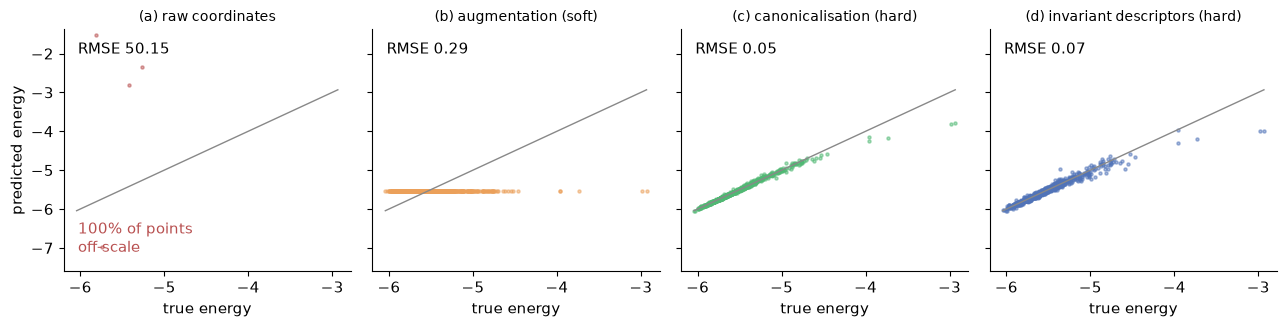

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharex=True, sharey=True)
lo, hi = E_test.min().item(), E_test.max().item()
for ax, k in zip(axes, "abcd"):
    ax.plot([lo, hi], [lo, hi], color=GREY, lw=1)
    ax.scatter(E_test, preds[k], s=5, alpha=0.5, color=COLORS[k])
    ax.set_title(LABELS[k], fontsize=10)
    ax.text(0.05, 0.9, f"RMSE {rmse(preds[k], E_test):.2f}", transform=ax.transAxes)
    if k == "a":
        frac = ((preds[k] - E_test).abs() > hi - lo).float().mean().item()
        ax.text(0.05, 0.08, f"{100 * frac:.0f}% of points\noff-scale", transform=ax.transAxes, color=RED)
    ax.set_xlabel("true energy")
axes[0].set_ylabel("predicted energy")
axes[0].set_ylim(lo - 0.5 * (hi - lo), hi + 0.5 * (hi - lo))
fig.tight_layout()
fig.savefig("figures/fig_II_parity.pdf")
plt.show()

## Test 2: data efficiency
Now the training data come in **random orientations and atom orders** (the realistic
case), and we vary the number of training configurations.

30 {'a': 0.415, 'b': 0.292, 'c': 0.331, 'd': 0.182}


100 {'a': 0.407, 'b': 0.289, 'c': 0.167, 'd': 0.118}


300 {'a': 0.401, 'b': 0.288, 'c': 0.076, 'd': 0.109}


1000 {'a': 0.414, 'b': 0.288, 'c': 0.051, 'd': 0.108}


3000 {'a': 0.328, 'b': 0.288, 'c': 0.038, 'd': 0.105}


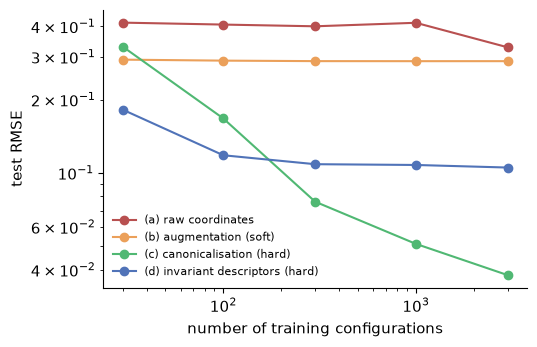

In [9]:
X_pool_rot = rotate_permute(X_pool, torch.Generator().manual_seed(7))
sizes = [30, 100, 300, 1000, 3000]
curves = {k: [] for k in "abcd"}
for n in sizes:
    for k in "abcd":
        m = train(k, X_pool_rot[:n], E_pool[:n], steps=1500)
        curves[k].append(rmse(predict(m, X_test), E_test))
    print(n, {k: round(v[-1], 3) for k, v in curves.items()})

fig, ax = plt.subplots(figsize=(5.5, 3.6))
for k in "abcd":
    ax.loglog(sizes, curves[k], "o-", color=COLORS[k], label=LABELS[k])
ax.set_xlabel("number of training configurations")
ax.set_ylabel("test RMSE")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig("figures/fig_II_learning_curve.pdf")
plt.show()

## Test 3: the weak spot of canonicalisation
Move one atom smoothly so that two atoms swap places in the sorting order.
The true energy is smooth; the canonicalised model sees its input vector jump.

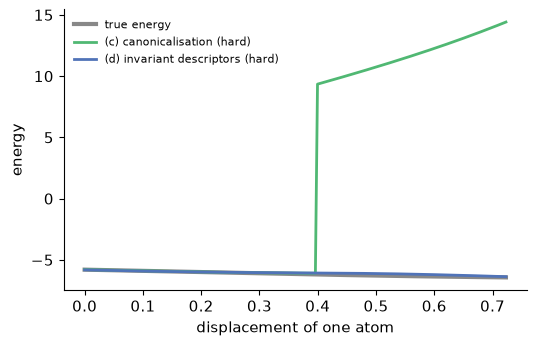

In [10]:
Yref = canonicalise(X_ref[None])[0]
proj = Yref @ U_SORT
order = torch.argsort(proj)
gaps = torch.diff(proj[order])
a = int(torch.argmin(gaps))
i_lo, i_hi = order[a], order[a + 1]          # canonical indices of the closest pair
# direction U_SORT expressed in the original frame
Xc = X_ref - X_ref.mean(0)
_, vecs = torch.linalg.eigh(Xc.T @ Xc)
sign = torch.sign(((Xc @ vecs) ** 3).sum(0))
u_world = vecs @ (sign * U_SORT)
# find which original atom is canonical atom i_lo: match positions
can_pos = Yref[i_lo]
orig = int(torch.argmin(((Xc @ vecs) * sign - can_pos).norm(dim=1)))
s = torch.linspace(0, 2.2 * gaps[a].item(), 200)
X_path = X_ref[None].repeat(len(s), 1, 1)
X_path[:, orig] += s[:, None] * u_world
E_path = energy(X_path)
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(s, E_path, color=GREY, lw=3, label="true energy")
for k in "cd":
    ax.plot(s, predict(models[k], X_path), color=COLORS[k], lw=2, label=LABELS[k])
ax.set_xlabel("displacement of one atom")
ax.set_ylabel("energy")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig("figures/fig_II_canon_path.pdf")
plt.show()

## Bonus: forces as $F=-\nabla E_\theta$
With model (d), forces come from automatic differentiation of the energy:
they are conservative **by construction** (a hard constraint that is not a symmetry).

In [11]:
Xf = X_test[:200].clone().requires_grad_(True)
(F_true,) = torch.autograd.grad(-energy(Xf).sum(), Xf)
Xg = X_test[:200].clone().requires_grad_(True)
(F_pred,) = torch.autograd.grad(-models["d"](Xg).sum(), Xg)
print(f"force RMSE of model (d), never trained on forces: {rmse(F_pred, F_true):.2f} "
      f"(force scale {F_true.std():.2f})")

print(f"total runtime: {time.time() - t_start:.0f} s")

force RMSE of model (d), never trained on forces: 0.70 (force scale 2.73)
total runtime: 44 s
